# PósTech FIAP - IA para Devs (Turma 9IADT)
## Tech Challenge - Fase 1
**Sistema de suporte ao diagnóstico médico do cancêr de mama**

---

| Aluno | RM |
|--------|------------------|
| Antonio |  |
| Renato Mattos |  |
| Vinicius Geisler |  |
| Marcelo |  |
| Vinicius Blasque |  |

---

**Objetivo:** Construir um modelo de analise de dados de exames para classificação de tumores como benignos ou malignos, servindo como ferramenta de apoio ao diagnóstico

**Dataset principal:** [Breast Cancer Wisconsin](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)

---


In [39]:
# Imports gerais
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

## Análise dos dados

In [40]:
dataset = pd.read_csv("data/breast-cancer-wisconsin-diagnostic-data-set.csv")

In [41]:
dataset.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [42]:
# Limpeza de colunas desnecessárias
dataset = dataset.drop(columns=['id', 'Unnamed: 32'])
dataset.shape

(569, 31)

In [43]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

Identificamos que a maioria dos dados estão em formato númerico, apenas a feature "diagnosis" é string.
Não identificamos campos nulos

In [44]:
set(dataset["diagnosis"])

{'B', 'M'}

In [45]:
dataset["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

A feature diagnosis possui apenas dois valores possiveis (B e M), send B = Benigno e M = Maligno.
A distribuição entre os valores esta aproximadamente 60% B e 40% M.

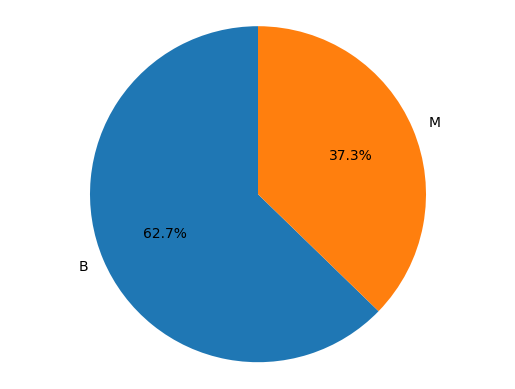

In [46]:
labels = dataset["diagnosis"].value_counts().index
sizes = dataset["diagnosis"].value_counts().values

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.show()

In [47]:
dataset.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


As escalas das features variam muito (ex: area_mean vai de 143 a 2501, enquanto smoothness_mean vai de 0.05 a 0.16). Isso significa que precisaremos normalizar os dados antes da modelagem.

array([[<Axes: title={'center': 'radius_mean'}>,
        <Axes: title={'center': 'texture_mean'}>,
        <Axes: title={'center': 'perimeter_mean'}>,
        <Axes: title={'center': 'area_mean'}>,
        <Axes: title={'center': 'smoothness_mean'}>],
       [<Axes: title={'center': 'compactness_mean'}>,
        <Axes: title={'center': 'concavity_mean'}>,
        <Axes: title={'center': 'concave points_mean'}>,
        <Axes: title={'center': 'symmetry_mean'}>,
        <Axes: title={'center': 'fractal_dimension_mean'}>],
       [<Axes: title={'center': 'radius_se'}>,
        <Axes: title={'center': 'texture_se'}>,
        <Axes: title={'center': 'perimeter_se'}>,
        <Axes: title={'center': 'area_se'}>,
        <Axes: title={'center': 'smoothness_se'}>],
       [<Axes: title={'center': 'compactness_se'}>,
        <Axes: title={'center': 'concavity_se'}>,
        <Axes: title={'center': 'concave points_se'}>,
        <Axes: title={'center': 'symmetry_se'}>,
        <Axes: title={'ce

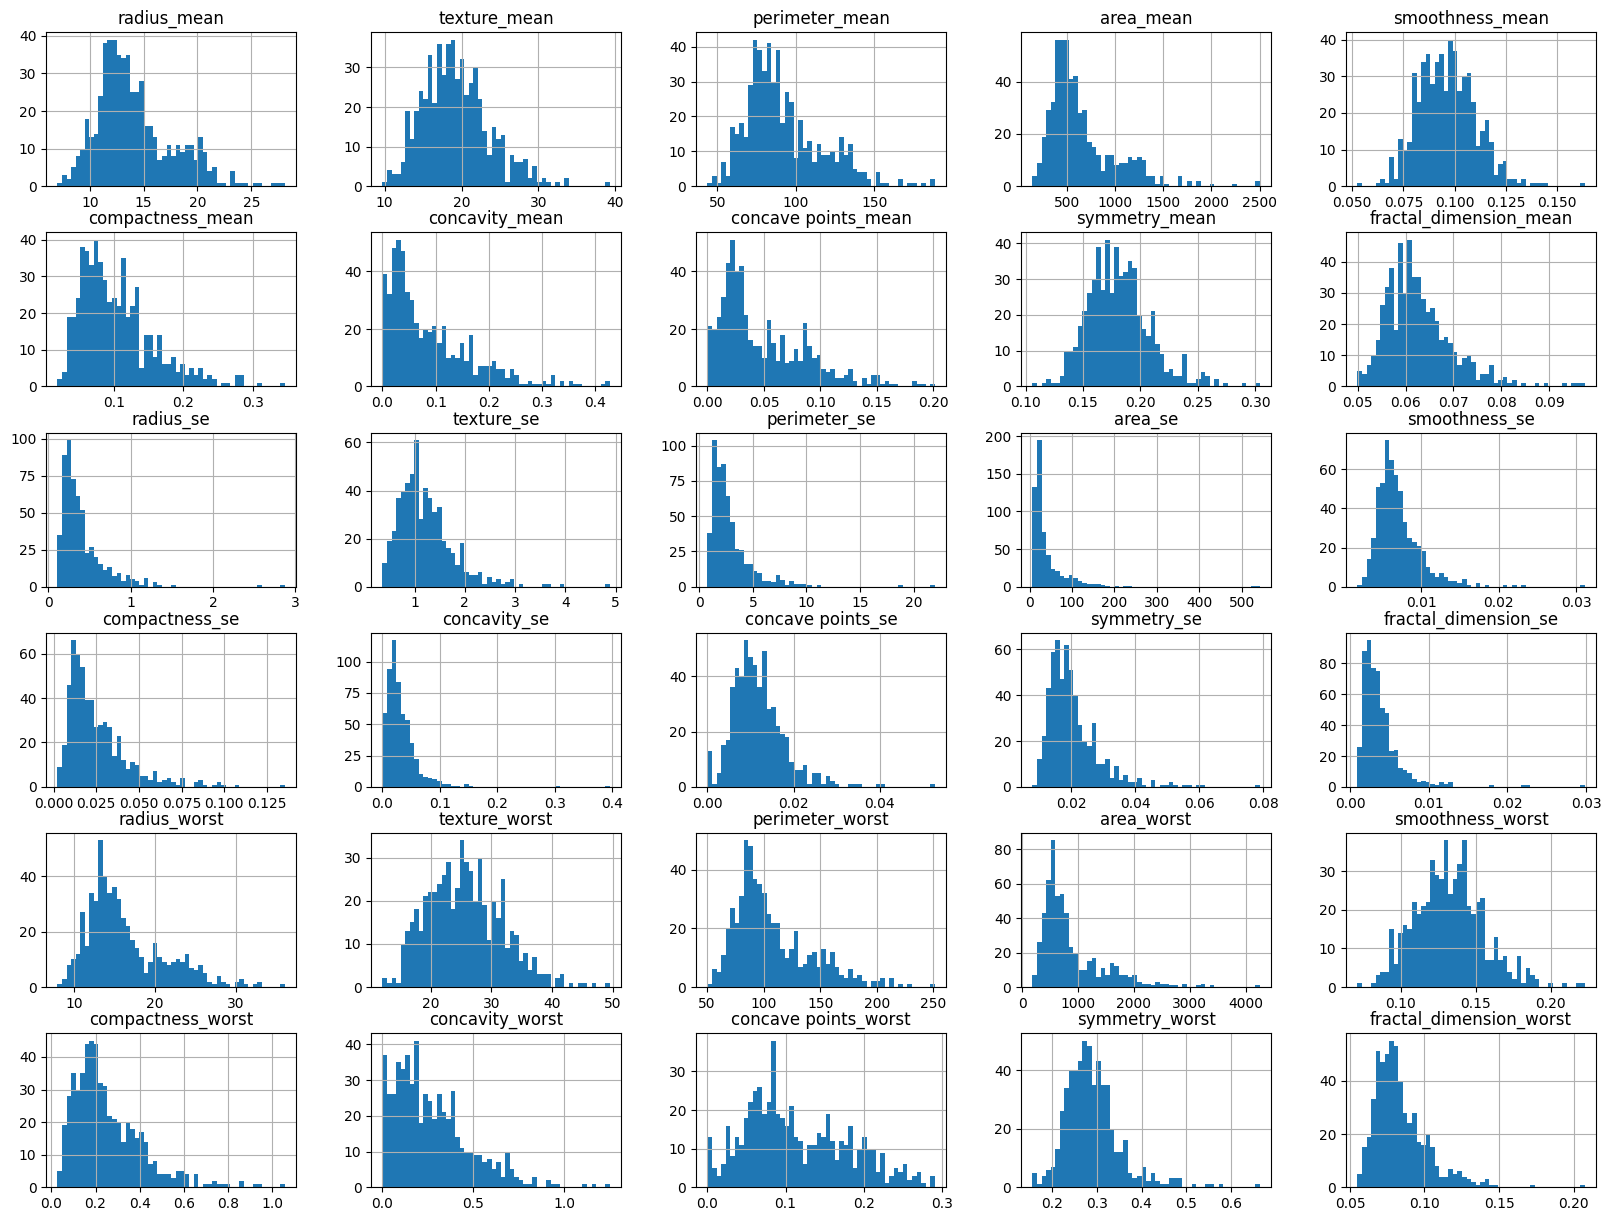

In [48]:
dataset.hist(bins=50, figsize=(20,15))

## Analise de matriz de correlação e PCA

In [49]:
# Criando dataframe somente com as variáveis numéricas de entrada
dataset_numerico = dataset.select_dtypes([np.number])

# Calcula a matriz de correlação
correlation_matrix = dataset_numerico.corr()

correlation_matrix

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
radius_mean,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
fractal_dimension_mean,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.253691,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297


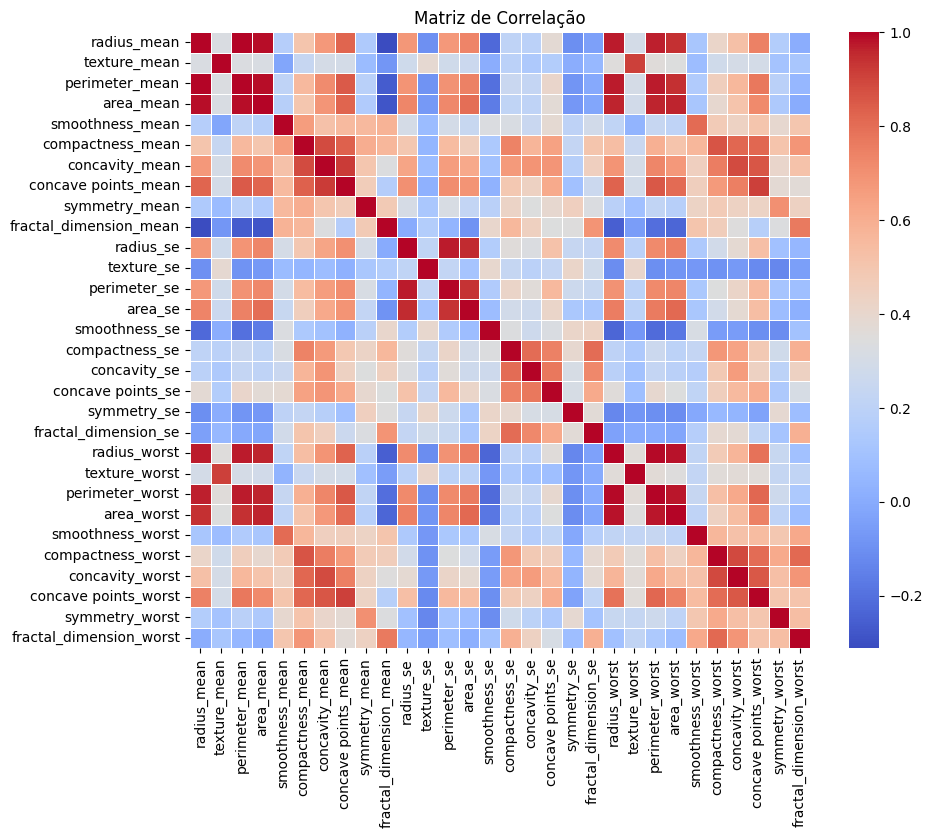

In [50]:
# Visualização da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação')
plt.show()

In [51]:
# Verifica valores nulos
dataset_numerico.isnull().sum()

radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [52]:
# Verifica valores nulos usando isna()
dataset_numerico.isna().sum()

radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

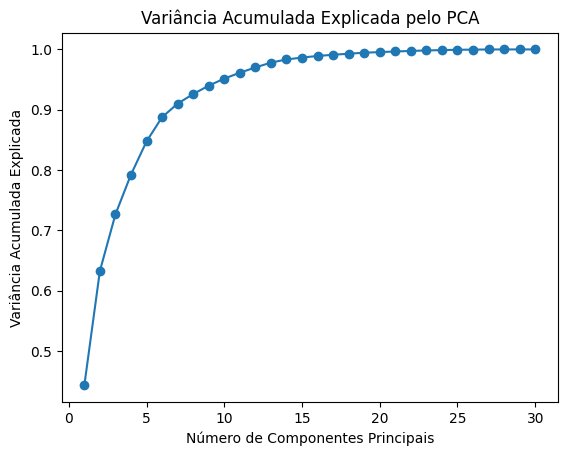

In [53]:
# Padroniza as variáveis
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer
# Preenche os valores NaN com a média das colunas
imputer = SimpleImputer(strategy='mean')
dataset_numerico = pd.DataFrame(
    imputer.fit_transform(dataset_numerico), 
    columns=dataset_numerico.columns)

scaler = StandardScaler()
dataset_padronizado = scaler.fit_transform(dataset_numerico)

# Calcula a variância explicada acumulada
pca = PCA()
pca.fit(dataset_padronizado)
variancia_cumulativa = np.cumsum(pca.explained_variance_ratio_)

# Visualização da variância explicada acumulada
plt.plot(range(1, len(variancia_cumulativa) + 1), variancia_cumulativa, marker='o')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Acumulada Explicada')
plt.title('Variância Acumulada Explicada pelo PCA')
plt.show()

In [54]:
# Vamos definir um limiar de 80%, ou seja, queremos obter uma porcentagem de explicancia sobre
# nossos dados de igual a 80%
limiar_de_variancia = 0.80

# Encontrar o número de componentes necessários para atingir ou ultrapassar o limiar
num_de_pca = np.argmax(variancia_cumulativa >= limiar_de_variancia) + 1

print(f"Número de Componentes para {limiar_de_variancia * 100}% da Variância: {num_de_pca}")

# Inicializa o objeto PCA
pca = PCA(n_components=num_de_pca)
# Aplica o PCA aos dados padronizados
principal_components = pca.fit_transform(dataset_padronizado)

# Exibe a proporção de variância explicada
explained_variance_ratio = pca.explained_variance_ratio_
print(explained_variance_ratio)

# Pegando o número de componentes principais gerados
num_components = principal_components.shape[1]
# Gerando uma lista para cada PCA
column_names = [f'PC{i}' for i in range(1, num_components + 1)]
# Criando um novo dataframe para visualizarmos como ficou nossos dados reduzidos com o PCA
pca_df = pd.DataFrame(data=principal_components, columns=column_names)

pca_df

Número de Componentes para 80.0% da Variância: 5
[0.44272026 0.18971182 0.09393163 0.06602135 0.05495768]


,PC1,PC2,PC3,PC4,PC5
0,9.192837,1.948583,-1.123166,-3.633731,1.195110
1,2.387802,-3.768172,-0.529293,-1.118264,-0.621775
2,5.733896,-1.075174,-0.551748,-0.912083,0.177086
3,7.122953,10.275589,-3.232790,-0.152547,2.960878
4,3.935302,-1.948072,1.389767,-2.940639,-0.546747
...,...,...,...,...,...
564,6.439315,-3.576817,2.459487,-1.177314,0.074824
565,3.793382,-3.584048,2.088476,2.506028,0.510723
566,1.256179,-1.902297,0.562731,2.089227,-1.809991
567,10.374794,1.672010,-1.877029,2.356031,0.033742


In [61]:
# Comparacao de desempenho com e sem PCA
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

X = dataset_numerico.copy()
y = dataset["diagnosis"].map({"B": 0, "M": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

modelos = {
    "LogisticRegression_sem_PCA": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=42))
    ]),
    "LogisticRegression_com_PCA": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=num_de_pca)),
        ("model", LogisticRegression(max_iter=5000, random_state=42))
    ]),
    "KNeighborsClassifier_sem_PCA": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=3))
    ]),
    "KNeighborsClassifier_com_PCA": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=num_de_pca)),
        ("model", KNeighborsClassifier(n_neighbors=3))
    ]),
    "RandomForest_sem_PCA": Pipeline([
        ("model", RandomForestClassifier(n_estimators=300, random_state=42))
    ]),
    "RandomForest_com_PCA": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=num_de_pca)),
        ("model", RandomForestClassifier(n_estimators=300, random_state=42))
    ])
}

resultados = []

for nome, pipeline in modelos.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    resultados.append({
        "modelo": nome,
        "accuracy_teste": accuracy_score(y_test, y_pred)
    })

comparacao_modelos = pd.DataFrame(resultados).sort_values(by="accuracy_teste", ascending=False)
comparacao_modelos

,modelo,accuracy_teste
1,LogisticRegression_com_PCA,0.973684
4,RandomForest_sem_PCA,0.973684
0,LogisticRegression_sem_PCA,0.964912
5,RandomForest_com_PCA,0.947368
3,KNeighborsClassifier_com_PCA,0.938596
2,KNeighborsClassifier_sem_PCA,0.938596


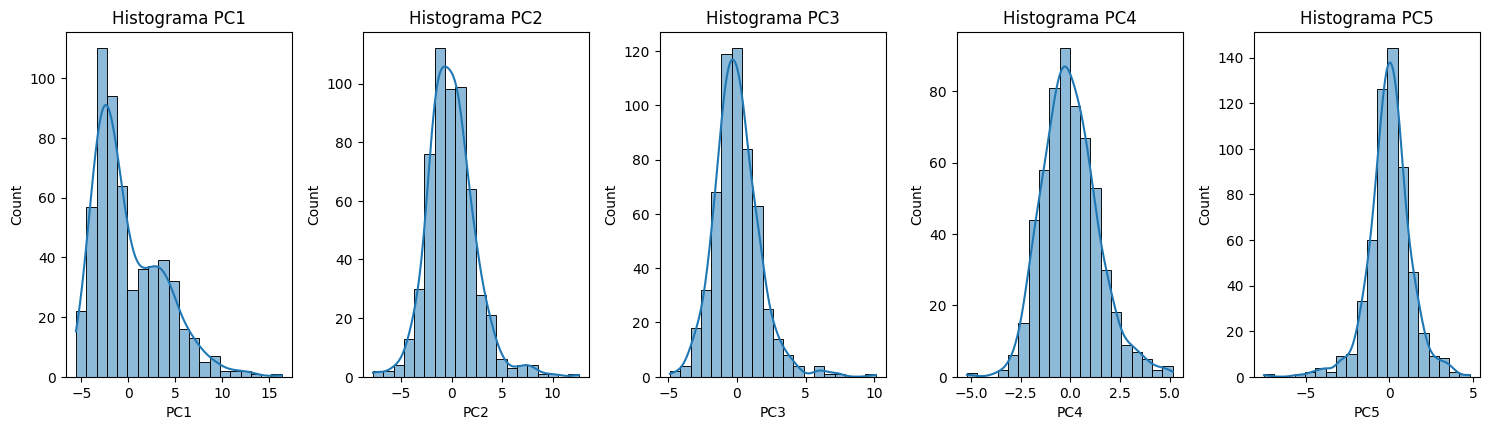

In [56]:
# Visualizacao da distribuicao dos componentes principais
plt.figure(figsize=(15, 8))
for i, col in enumerate(pca_df.columns[:10]):
    plt.subplot(2, 5, i + 1)
    sns.histplot(pca_df[col], bins=20, kde=True)
    plt.title(f'Histograma {col}')
plt.tight_layout()
plt.show()

In [57]:
from scipy.stats import shapiro

# Analise da distribuição dos componentes após o PCA
for column in pca_df.columns:
    stat, p_value = shapiro(pca_df[column])
    print(f'Variável: {column}, Estatística de teste: {stat}, Valor p: {p_value}')

    if p_value > 0.05:
        print(f'{column} apresenta distribuição próxima de normalidade.\n')
    else:
        print(f'{column} não apresenta distribuição próxima de normalidade.\n')

Variavel: PC1, Estatistica de teste: 0.9139439437830323, Valor p: 1.8987540424390222e-17
PC1 nao apresenta distribuicao proxima de normalidade neste teste.

Variavel: PC2, Estatistica de teste: 0.9593928650814297, Valor p: 2.0128944633202058e-11
PC2 nao apresenta distribuicao proxima de normalidade neste teste.

Variavel: PC3, Estatistica de teste: 0.9506966332294975, Valor p: 7.620093055934491e-13
PC3 nao apresenta distribuicao proxima de normalidade neste teste.

Variavel: PC4, Estatistica de teste: 0.9829874989144588, Valor p: 3.4025480513643e-06
PC4 nao apresenta distribuicao proxima de normalidade neste teste.

Variavel: PC5, Estatistica de teste: 0.9514758257465233, Valor p: 1.0051271030590186e-12
PC5 nao apresenta distribuicao proxima de normalidade neste teste.



### Interpretação do PCA

Na avaliação manual com separação entre treino e teste, o PCA não prejudicou o desempenho e chegou ao melhor resultado junto com um dos modelos sem PCA. Isso indica que a redução de dimensionalidade é uma estratégia interessante e com menor complexidade de dados.

## Avaliação final do modelo

Como houve empate no melhor resultado de acurácia no teste manual, foi escolhido o LogisticRegression_com_PCA como modelo final por ser mais simples de interpretar e consistente com a etapa de redução de dimensionalidade analisada anteriormente.

In [63]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

modelo_final = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=num_de_pca)),
    ("model", LogisticRegression(max_iter=5000, random_state=42))
])

modelo_final.fit(X_train, y_train)
y_pred_final = modelo_final.predict(X_test)

print(f"Acurácia no teste: {accuracy_score(y_test, y_pred_final):.4f}")
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_final, target_names=["Benigno", "Maligno"]))

Acurácia no teste: 0.9737

Relatório de classificação:
              precision    recall  f1-score   support

     Benigno       0.97      0.99      0.98        72
     Maligno       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## Conclusão final

Com os testes que fizemos, deu para ver que os dados têm um bom potencial para classificação e que o modelo conseguiu separar bem os casos benignos e malignos. A redução de dimensionalidade com PCA funcionou bem e, no nosso teste manual, o modelo final teve um resultado muito bom.

No fim, a Logistic Regression com PCA foi uma escolha interessante porque manteve um desempenho alto e ainda trabalhou com menos dimensões.